In [1]:
import pandas as pd

data = pd.read_csv(r'G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_dollar_bars.csv')
data['timestamp'] = pd.to_datetime(data['timestamp'])

In [2]:
def getDailyVol(close, span0=100, method='ewm'):
    """
    Calculate daily volatility.
    
    Args:
        close: pd.Series with datetime index and close prices
        span0: EWM span for volatility calculation (default 100)
        method: 'ewm' (exponential weighted) or 'rolling' (standard rolling)
    
    Returns:
        pd.Series with daily volatility
    """
    if not isinstance(close, pd.Series):
        raise ValueError("close must be a pd.Series")
    
    if len(close) < 2:
        raise ValueError("close must have at least 2 values")
    
    # More idiomatic way: use pct_change() for daily returns
    daily_returns = close.pct_change()
    
    # Calculate volatility
    if method == 'ewm':
        daily_vol = daily_returns.ewm(span=span0).std()
    elif method == 'rolling':
        daily_vol = daily_returns.rolling(window=span0).std()
    else:
        raise ValueError("method must be 'ewm' or 'rolling'")
    
    return daily_vol


# Alternative: More efficient for irregular data
def getDailyVol_irregular(close, span0=100):
    """
    Calculate daily volatility for potentially irregular time series.
    Handles gaps in data by computing actual day-over-day returns.
    
    Args:
        close: pd.Series with datetime index and close prices
        span0: EWM span for volatility calculation
    
    Returns:
        pd.Series with daily volatility
    """
    # Resample to daily frequency (forward fill if missing)
    daily_close = close.resample('D').last().fillna(method='ffill')
    daily_returns = daily_close.pct_change()
    daily_vol = daily_returns.ewm(span=span0).std()
    
    return daily_vol


close = data['Close']
close.index = data['timestamp']
daily_vol = getDailyVol(close)

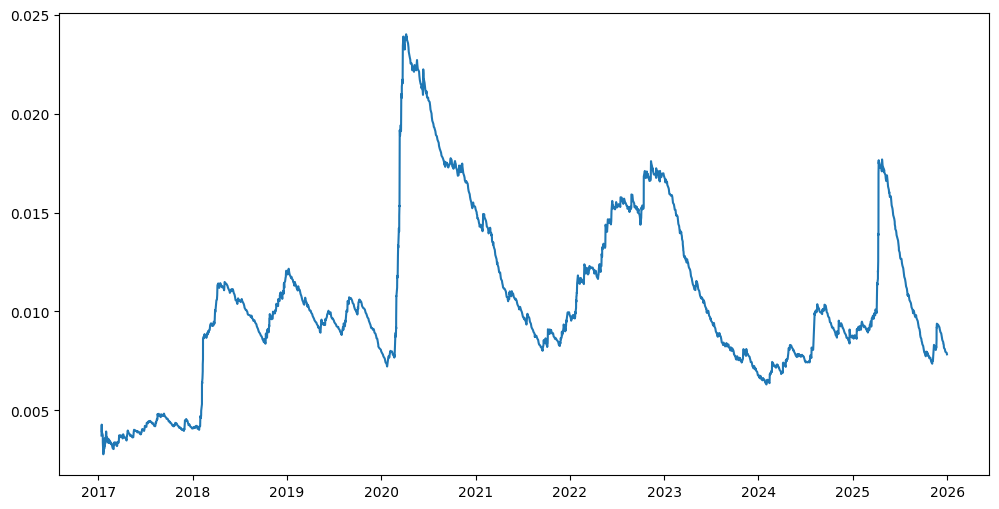

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(daily_vol.index, daily_vol.values)


In [4]:
mean_vol = daily_vol.mean()
print(f"Mean daily volatility: {mean_vol:.6f}")

Mean daily volatility: 0.010308


In [5]:
#Create a CUSUM filter
def cusum_filter(data, threshold):
    """
    CUSUM filter to detect significant price movements.
    
    Args:
        data: pd.DataFrame with 'Close' and 'timestamp' columns
        threshold: Threshold for CUSUM signals
    
    Returns:
        pd.DataFrame with event information (index, timestamp, signal_type)
    """
    # Create a copy to avoid modifying input
    df = data.copy()
    df['returns'] = df['Close'].pct_change()
    
    cusum_pos = 0.0
    cusum_neg = 0.0
    events = []
    
    for i in range(1, len(df)):
        # Update CUSUM values
        cusum_pos = max(0, cusum_pos + df.at[i, 'returns'])
        cusum_neg = min(0, cusum_neg + df.at[i, 'returns'])
        
        # Positive signal
        if cusum_pos > threshold:
            print(f"Positive CUSUM signal at index {i}, timestamp: {df.at[i, 'timestamp']}")
            events.append({
                'index': i,
                'timestamp': df.at[i, 'timestamp'],
                'signal_type': 'positive',
                'cusum_value': cusum_pos
            })
            cusum_pos = 0  # Reset after signal
            
        # Negative signal
        if cusum_neg < -threshold:
            print(f"Negative CUSUM signal at index {i}, timestamp: {df.at[i, 'timestamp']}")
            events.append({
                'index': i,
                'timestamp': df.at[i, 'timestamp'],
                'signal_type': 'negative',
                'cusum_value': cusum_neg
            })
            cusum_neg = 0  # Reset after signal
    
    return pd.DataFrame(events)

In [6]:
cusum_events = cusum_filter(data, threshold=3*mean_vol)  # Example threshold

#Number of events
print(f"Number of CUSUM events detected: {len(cusum_events)}")
print(f"Number of prices in total: {len(data)}")

Positive CUSUM signal at index 36, timestamp: 2017-02-14 19:49:00
Positive CUSUM signal at index 121, timestamp: 2017-05-24 20:28:00
Positive CUSUM signal at index 163, timestamp: 2017-08-08 17:10:00
Positive CUSUM signal at index 187, timestamp: 2017-09-13 20:13:00
Positive CUSUM signal at index 207, timestamp: 2017-10-20 13:56:00
Positive CUSUM signal at index 230, timestamp: 2017-11-28 20:33:00
Positive CUSUM signal at index 257, timestamp: 2018-01-03 19:21:00
Positive CUSUM signal at index 267, timestamp: 2018-01-17 21:10:00
Negative CUSUM signal at index 283, timestamp: 2018-02-02 20:01:00
Negative CUSUM signal at index 286, timestamp: 2018-02-05 20:18:00
Positive CUSUM signal at index 291, timestamp: 2018-02-07 17:36:00
Negative CUSUM signal at index 294, timestamp: 2018-02-08 22:07:00
Positive CUSUM signal at index 297, timestamp: 2018-02-12 19:21:00
Positive CUSUM signal at index 305, timestamp: 2018-02-26 16:01:00
Negative CUSUM signal at index 309, timestamp: 2018-03-01 21:10

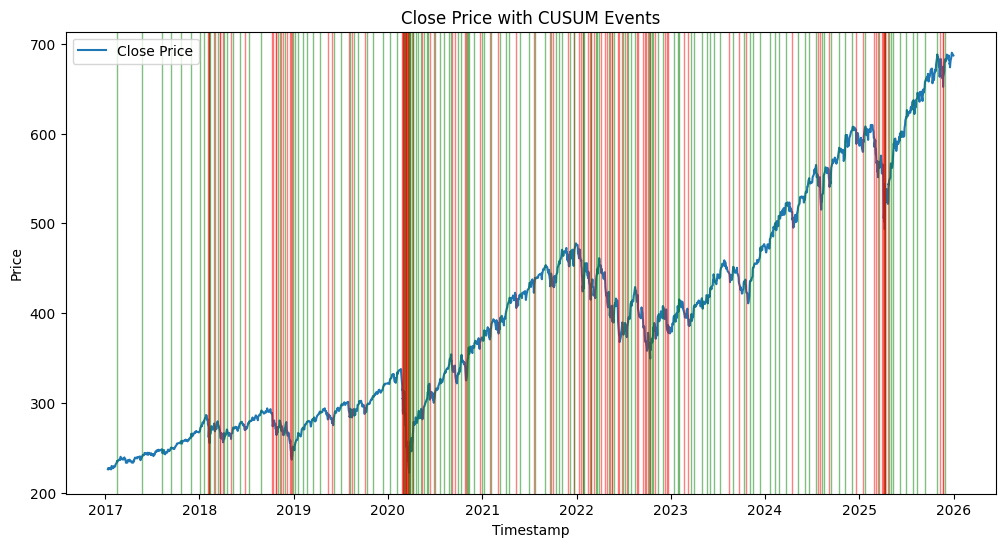

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(data['timestamp'], data['Close'], label='Close Price')
for _, event in cusum_events.iterrows():
    color = 'green' if event['signal_type'] == 'positive' else 'red'
    plt.axvline(x=event['timestamp'], color=color, alpha=0.5, linewidth=1)
plt.legend()
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('Close Price with CUSUM Events')
plt.show()

In [8]:
# Configure vertical-barrier mode: 'time' uses days, 'bars' uses number of bars after event
# Options:
# - t1_mode = 'time'  -> t1 = event_time + pd.Timedelta(days=num_days)
# - t1_mode = 'bars'  -> t1 = close.index[position_of_event + num_bars]

# Example configuration (choose one):
t1_mode = 'bars'   # 'time' or 'bars'
num_days = 5       # used when t1_mode == 'time'
num_bars = 252      # used when t1_mode == 'bars'

# Ensure event timestamps are sorted and are datetimes
tEvents = pd.DatetimeIndex(cusum_events['timestamp'].sort_values())
if tEvents.empty:
    t1 = pd.Series(dtype='datetime64[ns]')
else:
    if t1_mode == 'time':
        # target times = event time + vertical barrier (num_days)
        targets = tEvents + pd.Timedelta(days=num_days)

        # Find the first index in `close.index` that is >= each target.
        # `method='backfill'` returns the position of the first index greater-or-equal
        pos = close.index.get_indexer(targets, method='backfill')

        # get_indexer returns -1 for targets beyond the last index; filter those out
        mask = pos != -1

        # Build Series: index = original event times (filtered), values = corresponding vertical-barrier timestamps
        t1 = pd.Series(close.index[pos[mask]], index=tEvents[mask])

    elif t1_mode == 'bars':
        # For bar-count mode we find the price-bar position for each event and
        # add `num_bars` to obtain the vertical barrier position.
        # Use 'backfill' so the event aligns to the first price bar >= event time.
        event_pos = close.index.get_indexer(tEvents, method='backfill')

        # Events that are beyond the last price will have position -1 and are dropped.
        valid = event_pos != -1
        if valid.any():
            # Candidate barrier positions: event_pos + num_bars
            barrier_pos = event_pos[valid] + num_bars

            # Cap barrier positions at last available index
            last_pos = len(close) - 1
            barrier_pos = [p if p <= last_pos else last_pos for p in barrier_pos]

            # Map back to timestamps
            t1 = pd.Series([close.index[p] for p in barrier_pos], index=tEvents[valid])
        else:
            t1 = pd.Series(dtype='datetime64[ns]')

    else:
        raise ValueError("t1_mode must be 'time' or 'bars'")


In [9]:
#Show examples of tEvents and t1 for verification
print("\nCorresponding t1 (vertical barrier timestamps):")
print(t1.head())


Corresponding t1 (vertical barrier timestamps):
timestamp
2017-02-14 19:49:00   2018-02-06 15:23:00
2017-05-24 20:28:00   2018-07-05 19:54:00
2017-08-08 17:10:00   2018-10-09 14:35:00
2017-09-13 20:13:00   2018-11-01 19:32:00
2017-10-20 13:56:00   2018-12-05 00:24:00
dtype: datetime64[ns]


In [10]:
import pandas as pd
import warnings


def applyPtSlOnT1(close: pd.Series, events: pd.DataFrame, ptSl, molecule) -> pd.DataFrame:
    """
    Compute the first profit-taking and stop-loss hit times for a subset of events.

    Parameters
    ----------
    close : pd.Series
        Price series with a DatetimeIndex.
    events : pd.DataFrame
        Event table with at least the columns 't1', 'trgt', and 'side'.
    ptSl : sequence
        Two values: [profit_taking_multiplier, stop_loss_multiplier].
    molecule : iterable
        Subset of event timestamps to evaluate.

    Returns
    -------
    pd.DataFrame
        DataFrame indexed by event time with columns 'pt' and 'sl' holding the
        first timestamp where each barrier was hit.

    Notes
    -----
    The price path for each event starts at the bar after the event timestamp.
    That keeps the logic aligned with a post-entry evaluation and avoids
    look-ahead bias from using the event bar itself.
    """
    if not isinstance(close, pd.Series):
        raise ValueError("close must be a pd.Series")
    if not isinstance(events, pd.DataFrame):
        raise ValueError("events must be a pd.DataFrame")

    required = {"t1", "trgt", "side"}
    missing = required.difference(events.columns)
    if missing:
        raise ValueError(f"events is missing columns: {sorted(missing)}")
    if len(ptSl) != 2:
        raise ValueError("ptSl must have exactly two values: [pt_multiplier, sl_multiplier]")

    # Work only on the requested event subset.
    events_ = events.loc[pd.Index(molecule)].copy()

    # Initialize the output with missing hit times.
    out = pd.DataFrame(index=events_.index, columns=["pt", "sl"])
    out["pt"] = pd.NaT
    out["sl"] = pd.NaT
    last_close_time = close.index[-1]

    for loc, event in events_.iterrows():
        # Each event must start on a timestamp that exists in the price series.
        try:
            loc_pos = close.index.get_loc(loc)
        except KeyError:
            continue

        # The search window ends at the vertical barrier if present,
        # otherwise it extends to the last available price.
        end_time = event["t1"] if pd.notna(event["t1"]) else last_close_time
        if pd.isna(end_time):
            end_time = last_close_time
        if end_time > last_close_time:
            end_time = last_close_time
        end_pos = close.index.get_indexer([end_time], method="bfill")[0]

        # Start from the bar after entry to avoid using the entry bar itself.
        start_pos = loc_pos + 1
        if start_pos > end_pos:
            continue

        path = close.iloc[start_pos : end_pos + 1]
        if len(path) < 1:
            continue

        entry_price = path.iloc[0]

        # Measure returns relative to the entry price.
        # For long positions, positive returns help hit PT and negative returns
        # help hit SL. The side multiplier keeps the same logic working for shorts.
        if len(path) > 1:
            path_ret = (path.iloc[1:] / entry_price - 1.0) * event["side"]
        else:
            path_ret = pd.Series(dtype=float)

        # Profit-taking barrier.
        if ptSl[0] and ptSl[0] > 0 and not path_ret.empty:
            pt_level = ptSl[0] * event["trgt"]
            hit = path_ret[path_ret >= pt_level]
            if not hit.empty:
                out.loc[loc, "pt"] = hit.index[0]

        # Stop-loss barrier.
        if ptSl[1] and ptSl[1] > 0 and not path_ret.empty:
            sl_level = -ptSl[1] * event["trgt"]
            hit = path_ret[path_ret <= sl_level]
            if not hit.empty:
                out.loc[loc, "sl"] = hit.index[0]

    # Normalize the output columns to datetimes.
    out["pt"] = pd.to_datetime(out["pt"])
    out["sl"] = pd.to_datetime(out["sl"])
    return out



def getEvents(
    close: pd.Series,
    tEvents,
    ptSl,
    trgt: pd.Series,
    minRet: float,
    numThreads: int = 1,
    t1=False,
) -> pd.DataFrame:
    """
    Build the triple-barrier event table.

    Parameters
    ----------
    close : pd.Series
        Price series with a DatetimeIndex.
    tEvents : iterable
        Candidate event timestamps.
    ptSl : sequence
        Two values: [profit_taking_multiplier, stop_loss_multiplier].
    trgt : pd.Series
        Volatility or target series aligned to tEvents.
    minRet : float
        Minimum target size required for an event to be kept.
    numThreads : int, default 1
        Placeholder for parallel execution support. This notebook uses 1.
    t1 : pd.Series or False
        Vertical barrier timestamps aligned to tEvents. If False, no vertical
        barrier is applied.

    Returns
    -------
    pd.DataFrame
        Event table with columns 't1', 't_hit', 'trgt', and 'side'.
    """
    if not isinstance(close, pd.Series):
        raise ValueError("close must be a pd.Series")
    if numThreads != 1:
        raise NotImplementedError("Parallel execution not implemented; set numThreads=1")

    # Standardize and sort the candidate event index.
    tEvents = pd.Index(tEvents).sort_values()
    last_close_time = close.index[-1]

    # Align targets to the event timestamps and discard missing or tiny targets.
    trgt = trgt.reindex(tEvents)
    n_nan_trgt = trgt.isna().sum()
    if n_nan_trgt:
        warnings.warn(f"trgt has {n_nan_trgt} NaN values after reindex; these events are dropped.")
    trgt = trgt.dropna()
    trgt = trgt[trgt > minRet]

    # Build the vertical barrier series. If t1 is disabled, keep it as NaT.
    if t1 is False:
        t1_series = pd.Series(pd.NaT, index=tEvents, dtype="datetime64[ns]")
    else:
        if not isinstance(t1, pd.Series):
            raise ValueError(
                "t1 must be a pd.Series with a DatetimeIndex aligned to tEvents, not "
                f"{type(t1).__name__}. Pass t1=False to disable the vertical barrier."
            )
        t1_series = t1.reindex(tEvents)

    # Never let the vertical barrier extend past the last available price.
    t1_series = t1_series.clip(upper=last_close_time)

    if trgt.empty:
        return pd.DataFrame(columns=["t1", "t_hit", "trgt", "side"])

    # Event table starts from the surviving target timestamps.
    events = pd.DataFrame(index=trgt.index)
    events["t1"] = t1_series.reindex(events.index)
    events["trgt"] = trgt
    events["side"] = 1.0

    # Compute the first PT and SL hit timestamps for each event.
    barrier_hits = applyPtSlOnT1(
        close=close, events=events, ptSl=ptSl, molecule=events.index
    )

    # The effective event end time is the earliest of:
    # - the vertical barrier
    # - the profit-taking hit
    # - the stop-loss hit
    candidates = pd.concat(
        [events["t1"], barrier_hits["pt"], barrier_hits["sl"]], axis=1
    )
    candidates.columns = ["t1", "pt", "sl"]
    stacked = candidates.stack(dropna=True)
    if stacked.empty:
        events["t_hit"] = pd.NaT
    else:
        events["t_hit"] = stacked.groupby(level=0).min().reindex(events.index)

    return events

In [11]:
# Apply on data
events = getEvents(close=close, tEvents=tEvents, ptSl=[1, 1], trgt=10*daily_vol, minRet=0.01, t1=t1)

C:\Users\migue\AppData\Local\Temp\ipykernel_14276\4098919235.py:197: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = candidates.stack(dropna=True)


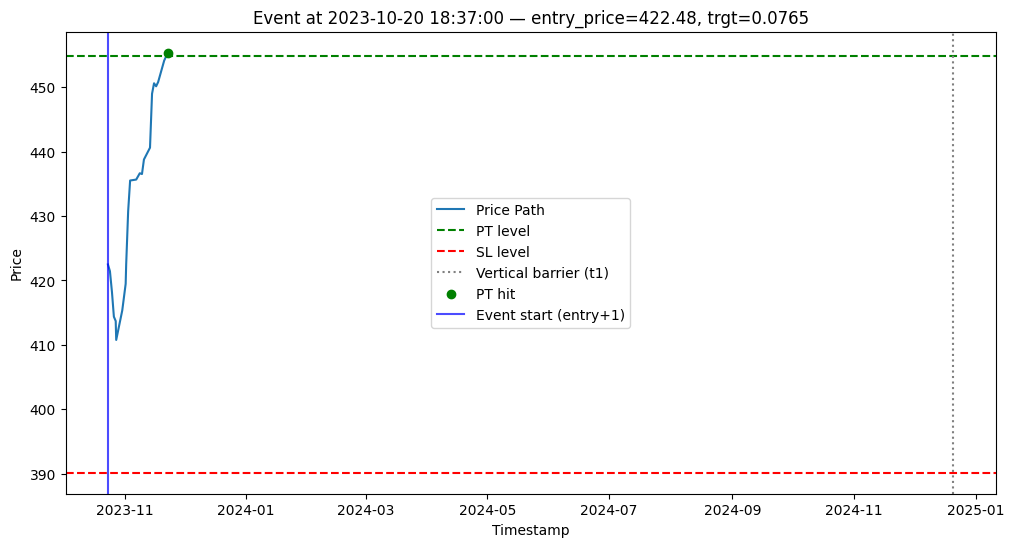

In [12]:
# Plot a single event path and the three barriers (pt, sl, vertical)
import matplotlib.pyplot as plt
# choose an event (first one here)
if events.empty:
    print('No events to plot')
else:
    event_id = events.sample(n=1).index[0]  # Randomly sample one event for plotting
    event = events.loc[event_id]
    start = event_id
    # Align plotting to the same post-entry definition used in applyPtSlOnT1
    try:
        start_pos = close.index.get_loc(start) + 1
    except KeyError:
        print('Event start not found in price index; skipping')
        start_pos = None
    if start_pos is None or start_pos >= len(close):
        print('No post-entry bar available; skipping plot')
    else:
        vertical_end = event['t1'] if pd.notna(event['t1']) else close.index[-1]
        hit_end = event['t_hit'] if 't_hit' in event.index and pd.notna(event['t_hit']) else vertical_end
        end_pos = close.index.get_indexer([hit_end], method='bfill')[0]
        if end_pos == -1 or start_pos > end_pos:
            print('No valid path between entry+1 and event end; skipping plot')
        else:
            path = close.iloc[start_pos : end_pos + 1].copy()
            entry_price = path.iloc[0]
            trgt = event['trgt']
            side = event['side']
            # ptSl used when creating events was [1,1] so use same here
            pt_level = 1.0 * trgt
            sl_level = -1.0 * trgt
            pt_price = entry_price * (1.0 + side * pt_level)
            sl_price = entry_price * (1.0 + side * sl_level)
            # determine which barrier (if any) was hit first by recomputing hits for this event
            hits = applyPtSlOnT1(close=close, events=events, ptSl=[1,1], molecule=[event_id])
            pt_hit = hits.loc[event_id, 'pt'] if pd.notna(hits.loc[event_id, 'pt']) else pd.NaT
            sl_hit = hits.loc[event_id, 'sl'] if pd.notna(hits.loc[event_id, 'sl']) else pd.NaT
            plt.figure(figsize=(12,6))
            plt.plot(path.index, path.values, label='Price Path')
            plt.axhline(y=pt_price, color='green', linestyle='--', label='PT level')
            plt.axhline(y=sl_price, color='red', linestyle='--', label='SL level')
            plt.axvline(x=vertical_end, color='gray', linestyle=':', label='Vertical barrier (t1)')
            if pd.notna(pt_hit) and pt_hit in close.index:
                plt.scatter([pt_hit], [close.loc[pt_hit]], color='green', zorder=5, label='PT hit')
            if pd.notna(sl_hit) and sl_hit in close.index:
                plt.scatter([sl_hit], [close.loc[sl_hit]], color='red', zorder=5, label='SL hit')
            plt.axvline(x=close.index[start_pos], color='blue', linestyle='-', alpha=0.7, label='Event start (entry+1)')
            plt.title(f'Event at {start} — entry_price={entry_price:.2f}, trgt={trgt:.4f}')
            plt.xlabel('Timestamp')
            plt.ylabel('Price')
            plt.legend()
            plt.show()